# Get timeseries of GWLs of each CMIP6 model run

Requires separate loading of monthly _global_ (not truncated to land) data, which can be taken from `preprocess_cmip6_general.ipynb` by setting the `table_id` to `Amon` and the `subset_params` to global. 

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
from distributed import Client
import fsspec
import re
import os
import datetime
import xagg as xa
import warnings

from funcs_support import area_mean, get_params, utility_save, get_filepaths

dir_list = get_params()

# Get filesystem
#fs = fsspec.implementations.local.LocalFileSystem()

# Start dask client
client = Client()
display(client)

/glade/u/home/schwarzwald/.conda/envs/enso_imp/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 42683 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/schwarzwald/climate/proxy/42683/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/schwarzwald/climate/proxy/42683/status,Workers: 6
Total threads: 18,Total memory: 72.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46481,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/schwarzwald/climate/proxy/42683/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33645,Total threads: 3
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/schwarzwald/climate/proxy/40609/status,Memory: 12.00 GiB
Nanny: tcp://127.0.0.1:36549,


In [4]:
exps = ['historical','ssp245','ssp370','ssp585','ssp119']

gwls_base = {'year':slice(1850,1900)}

max_end_year = 2100

wwidth = 20

#freq = 'Amon'
freq = 'day'



In [12]:
# Get files from ESGF staging

df = get_filepaths(dir_list = STAGING_DIRECTORY
# Putting the file directory in the pangeo format b
df = df.rename({'model':'source_id','exp':'experiment_id','run':'member_id','varname':'variable_id','path':'zstore'},axis=1)
dfs = {exp:df.query('variable_id == "tas" and experiment_id == "'+exp+'"') for exp in np.unique(df['experiment_id'].values)}

In [21]:
modrun_groups = pd.concat([d for k,d in dfs.items()]).groupby(['source_id','member_id'])
modrun_groups = dict(tuple(modrun_groups))

keys_all = [k for k in modrun_groups]

#suffix = '_fromAmon'
suffix = '_wsomeESGFruns'
existing_file = dir_list['aux']+'gwl_ann_CMIP6_ALLEXPs_ALLRUNs_1860-2090'+suffix+'.nc'
#existing_file = None
if existing_file is not None:
    ds_existing = xr.open_dataset(existing_file)
    keys_existing = [(str(mod),str(exp)) for mod,exp in zip(ds_existing.model.values,ds_existing.experiment.values)]

#dss_all = []
fns_all = []
#existing_calcs = [(ds.model.values[0],ds.run.values[0]) for ds in dss_all]

for key in tqdm(keys_all):
    output_fn = dir_list['aux']+'gwl_ann_'+key[0]+'_ALLEXPs_'+key[1]+'.zarr'
    
    #if key in existing_calcs:
    #    continue
    #if fs.exists(output_fn):
    if os.path.exists(output_fn):
        fns_all.append(output_fn)
        continue

    group = modrun_groups[key]
    if 'historical' in group.experiment_id.values:
        #dsh = xr.open_zarr(group.iloc[group.experiment_id.values=='historical',:]['zstore'].values[0])
        dsh = xr.open_dataset(group.iloc[group.experiment_id.values=='historical',:]['zstore'].values[0]).load()

        dsh = dsh.drop_vars(['time_bounds','time_bnds'],errors='ignore')
    
        _has_baseperiod = dsh.time.dt.year.min()<=gwls_base['year'].start

        if 'lat' not in dsh.sizes:
            print(', '.join(key)+' has no rectangular grid, skipping for now.')
            continue
        if dsh.sizes['time'] < 20*12:
            print(', '.join(key)+' has < 20 years of data for the historical run, skipping...')
            continue
    else:
        print(', '.join(key)+' has no historical file, skipping.')
        continue    

    if existing_file is not None:
        dse_tmp = ds_existing.isel(memberid = (ds_existing.model == key[0]) & (ds_existing.run == key[1])).load()
        dse_tmp = dse_tmp.dropna(dim='memberid',how='all')
        dss = {str(exp):dse_tmp.isel(memberid = dse_tmp.experiment==exp) for exp in dse_tmp.experiment.values}
        dse_exps = dse_tmp.experiment.values
    else:
        dss = {}
        dse_exps = []
        
    if _has_baseperiod:
        with warnings.catch_warnings():
            warnings.filterwarnings('ignore') # Catching chunk warnings
            # manually setting chunks to avoid dtype object error if time is cftime
            dss = {**dss,**{row[1]['experiment_id']:xr.open_dataset(row[1]['zstore']).load().drop_vars(['time_bounds','time_bnds'],errors='ignore')
                   for row in group.iterrows() if row[1]['experiment_id'] not in dss}}

            dss['histfull'] = dsh
        try:
            for exp in dss:
                # I have 72 GB of RAM reserved. doing dask with netcdfs is awful. Let's just load. 
                dss[exp] = dss[exp].load()
                if 'lat' in dss[exp].sizes:
                    # Drop time duplicates (happens in a file or two)
                    dss[exp] = dss[exp].drop_duplicates('time')
                    
                    # Get global mean 
                    try:
                        dss[exp] = area_mean(dss[exp])
                    except:
                        raise ValueError('Issue with getting mean of '+', '.join(key)+', '+exp+', skipped (probably because non-rect. grid)')
            
                    # Get annual mean 
                    dss[exp] = dss[exp].resample(time='1YS').mean()
                    dss[exp]['time'] = dss[exp]['time'].dt.year
                    dss[exp] = dss[exp].rename({'time':'year'})
            
                    # Subset to years needed
                    dss[exp] = dss[exp].sel(year=slice(gwls_base['year'].start,max_end_year+int(np.ceil(wwidth/2))))
        except ValueError as e:
            print(e)
            #continue
    
        # Now, concatenate historical and future timeseries
        for exp in [exp for exp in dss if exp != 'historical' and exp not in dse_exps]:
            dss[exp] = xr.concat([dss['histfull'].sel(year=slice(None,2014)), #histfull is loaded anew even if historical already exists, thus allowing new 
                                  dss[exp].sel(year=slice(2015,None))],dim='year')

        del dss['histfull']
        # Now, 
        for exp in dss:
            # Get anomalies
            if 'tasanom' not in dss[exp]:
                dss[exp]['tasanom'] = dss[exp]['tas']-dss[exp]['tas'].sel(**gwls_base).mean('year')
        
                # Get 20-year running means
                dss[exp] = dss[exp].rolling(year=wwidth,center=True).mean()
            # Drop resultant nas from end of window
            dss[exp] = dss[exp].dropna('year')

            if 'experiment' not in dss[exp].coords:
                dss[exp] = dss[exp].expand_dims({'experiment':[exp],
                                                 'model':[key[0]],
                                                 'run':[key[1]]})
            else:
                dss[exp]['experiment'] = (['memberid'],[exp])
            if 'year' in dss[exp]['experiment'].sizes: # I think hat shouold be fixed by the line above (caused by having it originally be [exp])
                dss[exp]['experiment'] = dss[exp]['experiment'].isel(year=-1)
            if 'memberid' not in dss[exp].sizes:
                dss[exp] = dss[exp].stack(memberid = ['model','experiment','run']).reset_index(['memberid'])

        # Concatenate into single ds
        dss = xr.concat([ds for exp,ds in dss.items()],
              dim='memberid')

        # Compute (well, something triggers it anyways, sigh)
        #dss = dss.compute()
    
        # Concatenate 
        #dss_all.append(dss)

        # Save
        dss = dss.chunk({dim:-1 for dim in dss.sizes})
        utility_save(dss,output_fn)
        fns_all.append(output_fn)
    
    else:
        print(', '.join(key)+' historical does not cover the base period, skipping.')
        continue


  0%|          | 0/10 [00:00<?, ?it/s]

In [22]:
# Now, open all calculated files
dss_out = xr.concat([xr.open_zarr(fn).drop_vars(['height'],errors='ignore')
                     for fn in fns_all],
                    dim='memberid')#.reset_index('memberid')

# It's like 5 MB, no reason to actually chunk this
dss_out = dss_out.chunk({'year':-1,'memberid':-1})

# Drop unneeded variable and subset to just years processed
dss_out = dss_out.drop_vars(['bnds'],errors='ignore').sel(year=slice(gwls_base['year'].start+int(wwidth/2),
                                                     max_end_year-int(wwidth/2)))

dss_out = dss_out.load()

dss_out = xr.concat([dss_out[['tas','tasanom']],ds_existing[['tas','tasanom']]],dim='memberid')
#dss_out = dss_out.set_index(memberid = ['model','experiment','run']).drop_duplicates('memberid').reset_index('memberid')

dss_out['tasanom'].attrs = {'units':'K','long_name':'Rolling '+str(wwidth)+'-year mean of near-surface GMST anomalies (vs. '+str(gwls_base['year'].start)+'-'+str(gwls_base['year'].stop)+')',
                            'short_name':'GWL'}
dss_out['tas'].attrs = {'units':'K','long_name':'Rolling '+str(wwidth)+'-year mean of near-surface GMST',
                            'short_name':'near-surface GMST'}

dss_out.attrs['SOURCE'] = 'calculate_gwls_timeseries.ipynb'
dss_out.attrs['DESCRIPTION'] = ('GWLs vs. '+str(gwls_base['year'].start)+'-'+str(gwls_base['year'].stop)+', '+
                                ' '+str(wwidth)+'-year rolling averages of GMST. Concatenating historical and SSP* data with the same run id '+
                                '(though this can be problematic, since same run id does not guarantee same run. If this can be an issue, be wary '+
                                ' of exact values within 10 years of 2014).')
dss_out.attrs['INCLUSION_CRITERIA'] = ('All CMIP6 models, experiments, runs on LEAP-Pangeo with monthly near-surface air temperature '+
                                        'and a historical run starting in 1850 with the same ensemble member id, as of '+
                                       str(datetime.date.today())+'.')
#output_fn = '../aux_data/gwl_ann_CMIP6_ALLEXPs_ALLRUNs_'+str(gwls_base['year'].start+int(wwidth/2))+'-'+str(max_end_year-int(wwidth/2))+'.zarr'
# Because of zarr encoding issue, 
# detailed here: https://github.com/pydata/xarray/issues/3476#issuecomment-841692487
for var in dss_out.variables:
    dss_out[var].encoding.clear()

output_fn = '/gwl_ann_CMIP6_ALLEXPs_ALLRUNs_'+str(gwls_base['year'].start+int(wwidth/2))+'-'+str(max_end_year-int(wwidth/2))+suffix


# Save a local copy (it's 4 MB, it's fine)
utility_save(dss_out,
             dir_list['aux']+output_fn+'.nc')



../aux_data/gwl_ann_CMIP6_ALLEXPs_ALLRUNs_1860-2090_wsomeESGFruns.nc removed to allow overwrite!
../aux_data/gwl_ann_CMIP6_ALLEXPs_ALLRUNs_1860-2090_wsomeESGFruns.nc saved!


In [19]:
# Remove constituent files
for fn in fns_all:
    fs.rm(fn,recursive = True)

In [15]:
output_fn = '/gwl_ann_CMIP6_ALLEXPs_ALLRUNs_'+str(gwls_base['year'].start+int(wwidth/2))+'-'+str(max_end_year-int(wwidth/2))+'_from'+freq
output_fn

'/gwl_ann_CMIP6_ALLEXPs_ALLRUNs_1860-2090_fromAmon'

In [19]:
utility_save(dss_out,dir_list['aux']+output_fn+'.nc')

../aux_data//gwl_ann_CMIP6_ALLEXPs_ALLRUNs_1860-2090_fromAmon.nc saved!


## Diag figure

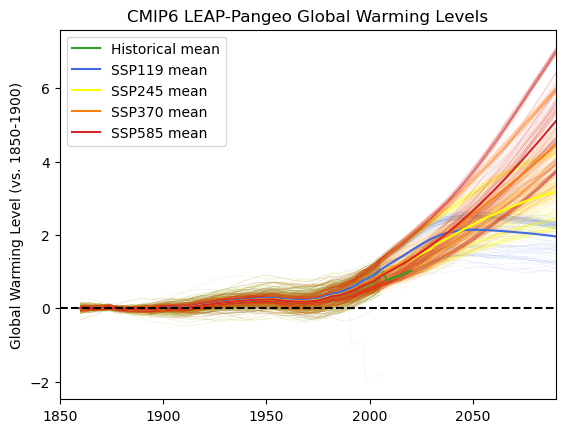

In [13]:
#dss_out = xr.open_zarr('gs://leap-persistent/ks905383/gwl_ann_CMIP6_ALLEXPs_ALLRUNs_1860-2090.zarr')
#dss_out = dss_out.load()

from matplotlib import pyplot as plt

colors = {'historical':'tab:green',
          'ssp119':'royalblue',
          'ssp245':'yellow',
          'ssp370':'tab:orange',
          'ssp585':'tab:red'}

ax = plt.subplot()

for exp in np.unique(dss_out.experiment.values):
    ds_tmp = dss_out.isel(memberid = (dss_out.experiment.values==exp))
    for i in range(ds_tmp.sizes['memberid']):
        ds_tmp.isel(memberid=i).tasanom.plot(color=colors[exp],alpha=0.2,linewidth=0.2)
for exp in np.unique(dss_out.experiment.values):
    ds_tmp = dss_out.isel(memberid = (dss_out.experiment.values==exp))
    ds_tmp.mean('memberid').tasanom.plot(color=colors[exp],
                                                            label=re.sub(r'^Ssp','SSP',exp.title())+' mean')

ax.axhline(0,color='k',linestyle='--')
ax.set_xlim(1850,2090)
ax.set_ylabel('Global Warming Level (vs. 1850-1900)')
ax.set_xlabel('')
ax.set_title('CMIP6 LEAP-Pangeo Global Warming Levels')
ax.legend()